# Clinical Trial - Subject Response Analysis for Different Medications

**By** Vedparkash Singh

In [110]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

---
## Part 2: Initial Analysis - Data Overview
**Bob's Question:** What is the frequency of each cell type in each sample?<br>
**Need to:** Display a summary table of the relative frequency of each cell population<br>
-For each sample, calculate the total number of cells by summing the counts across all five populations. <br>
-Then, compute the relative frequency of each population as a percentage of the total cell count for that sample. <br><br>
**Output:** Each row represents one population from one sample with columns `sample`, `total_count`, `population`, `count`, `percentage`

In [111]:
DB_PATH = 'cell_counts.db'

#read in dataframes from database
conn = sqlite3.connect(DB_PATH)
samples_df = pd.read_sql_query('SELECT * from samples',conn)
subjects_df = pd.read_sql_query('SELECT * from subjects', conn)
conn.close()

print('samples count is:' + str(len(samples_df)))
print('subjects count is:' + str(len(subjects_df)))

samples count is:10500
subjects count is:3500


In [112]:
POPULATIONS = ['b_cell','cd8_t_cell','cd4_t_cell','nk_cell','monocyte']

#total cells in the study
samples_df['total_count'] = samples_df[POPULATIONS].sum(axis=1)

#fill freq_df with frequencies for each sample
rows = []
for _, row in samples_df.iterrows():
    for pop in POPULATIONS:
        rows.append({
            'sample':row['sample'],
            'total_count':row['total_count'],
            'population':pop,
            'count':row[pop],
            'percentage': round((row[pop]/row['total_count'])*100,2)
        })

freq_df = pd.DataFrame(rows)
freq_df

,sample,total_count,population,count,percentage
0,sample00000,93214,b_cell,10908,11.70
1,sample00000,93214,cd8_t_cell,24440,26.22
2,sample00000,93214,cd4_t_cell,20491,21.98
3,sample00000,93214,nk_cell,13864,14.87
4,sample00000,93214,monocyte,23511,25.22
...,...,...,...,...,...
52495,sample10499,92418,b_cell,9258,10.02
52496,sample10499,92418,cd8_t_cell,29100,31.49
52497,sample10499,92418,cd4_t_cell,26769,28.97
52498,sample10499,92418,nk_cell,12895,13.95


In [113]:
avg_freq = freq_df.groupby('population')['percentage'].agg(['mean','std']).reset_index()
avg_freq

,population,mean,std
0,b_cell,9.882465,3.097183
1,cd4_t_cell,30.274958,4.813481
2,cd8_t_cell,24.905992,4.465312
3,monocyte,20.020018,4.192229
4,nk_cell,14.916589,3.727294


---
## Part 3 - Statistical Analysis

Bob wants to identify patterns that might predict treatment response and share those findings with his colleague Yah D'yada.

**Objective** Using the data reported in the summary table, provide functionality to
1. Compare the differences in cell population relative frequencies of melanoma patients recieving miraclib who respond vs don't respond. The overarching aim is to predict response to the treatment miraclib. Only include PBMC samples.
2. Visualize the population relative frequencies comparing responders vs non-responders using boxplot for each immune cell population
3. Report which cell populations have a significant difference in relative frequencies between responders and non-responders. Statistics are needed to support any conclusions to convince Yah of Bob's findings. 


In [ ]:
# Part 1 : Compare the differences in cell population relative frequencies between different responses

In [115]:
#Get the data of melanoma patients converted into a summary table

#we will join the samples and subjects tables, using subject as the common column
# filter out only subjects who match all of the restrictions listed
conn = sqlite3.connect(DB_PATH)
melanoma_df = pd.read_sql_query("""
    SELECT s.*, sub.condition, sub.treatment, sub.response, sub.subject, sub.project, sub.age, sub.sex
    FROM samples s
    JOIN subjects sub ON s.subject= sub.subject
    WHERE sub.condition = 'melanoma'
        AND sub.treatment = 'miraclib'
        AND s.sample_type = 'PBMC'
""", conn)
conn.close()

#create the sample table
melanoma_df['total_count'] = melanoma_df[POPULATIONS].sum(axis=1)

rows = []
for _, row in melanoma_df.iterrows():
    for pop in POPULATIONS:
        rows.append({
            'sample':row['sample'],
            'total_count':row['total_count'],
            'population':pop,
            'count':row[pop],
            'percentage': round((row[pop]/row['total_count'])*100,2),
            'response': row['response'],
            'project': row['project'],
            'age': row['age'],
            'sex': row['sex']
        })

melanoma_freq = pd.DataFrame(rows)
melanoma_freq

,sample,total_count,population,count,percentage,response,project,age,sex
0,sample00000,93214,b_cell,10908,11.70,no,prj1,57,M
1,sample00000,93214,cd8_t_cell,24440,26.22,no,prj1,57,M
2,sample00000,93214,cd4_t_cell,20491,21.98,no,prj1,57,M
3,sample00000,93214,nk_cell,13864,14.87,no,prj1,57,M
4,sample00000,93214,monocyte,23511,25.22,no,prj1,57,M
...,...,...,...,...,...,...,...,...,...
9835,sample10493,93386,b_cell,9683,10.37,yes,prj3,71,M
9836,sample10493,93386,cd8_t_cell,23974,25.67,yes,prj3,71,M
9837,sample10493,93386,cd4_t_cell,28536,30.56,yes,prj3,71,M
9838,sample10493,93386,nk_cell,13755,14.73,yes,prj3,71,M


In [116]:
diff_res = melanoma_freq['response'].unique()
print(diff_res)
for res in diff_res:
    print('--------'+res+'--------')
    df = melanoma_freq[melanoma_freq['response'] == res]
    res_avg_freq = df.groupby('population')['percentage'].agg(['mean','std']).reset_index()
    
    print(res_avg_freq)


['no' 'yes']
--------no--------
   population       mean       std
0      b_cell   9.996226  3.117840
1  cd4_t_cell  29.902369  4.824046
2  cd8_t_cell  24.943979  4.417015
3    monocyte  20.084256  4.010794
4     nk_cell  15.073036  3.767384
--------yes--------
   population       mean       std
0      b_cell   9.797452  3.322639
1  cd4_t_cell  30.537795  5.207477
2  cd8_t_cell  24.881762  4.914418
3    monocyte  19.941702  4.642376
4     nk_cell  14.840967  4.132101


**Conclusion** Cell population relative frequencies of melanoma patients recieving miraclib who respond vs don't respond are very similar. The mean and standard deviation of cell counts per cell population are almost identintical for both groups, which shows that cell counts and variation are identical in both groups. This does not give us a lot of insight on what factors may help predicting response to the treatment miraclib because both group on average are showing identical cell counts.

In [117]:
#2 Visualize the population relative frequencies between Responders and non-Responders using boxplot

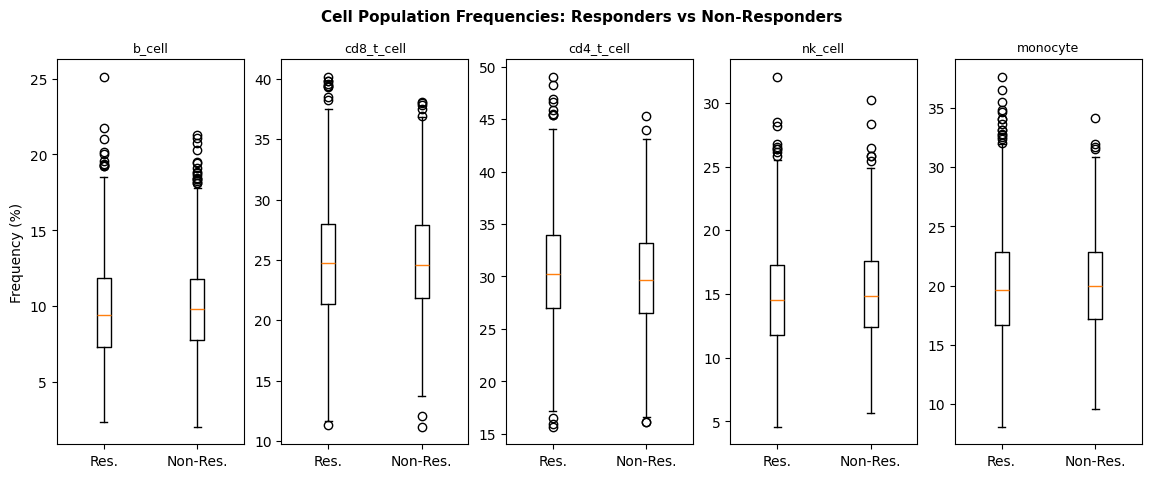

In [123]:
fig, axes = plt.subplots(1,5, figsize=(14,5)) 
fig.suptitle('Cell Population Frequencies: Responders vs Non-Responders', fontsize=11, fontweight='bold')

#for each cell type create a boxplot for res and non_res patients
for ax, pop in zip(axes, POPULATIONS):
    res = melanoma_freq[(melanoma_freq['population'] == pop) & (melanoma_freq['response'] == 'yes')]['percentage']
    non_res = melanoma_freq[(melanoma_freq['population'] == pop) & (melanoma_freq['response'] == 'no')]['percentage']
    
    ax.boxplot([res, non_res], labels = ['Res.','Non-Res.'])

    ax.set_title(pop, fontsize=9)
    ax.set_ylabel('Frequency (%)' if pop == POPULATIONS[0] else '')

In [124]:
# Part 3: Statistics to show any behavior

In [132]:
# before running any tests, let's find out if data is normally distributed

from scipy import stats
for pop in POPULATIONS:
    res = melanoma_freq[(melanoma_freq['population'] == pop) & (melanoma_freq['response'] == 'yes')]['percentage']
    non_res = melanoma_freq[(melanoma_freq['population'] == pop) & (melanoma_freq['response'] == 'no')]['percentage']

    _, res = stats.shapiro(res)
    _, non_res = stats.shapiro(non_res)

    res_normal = 'YES' if res > 0.05 else 'NO'
    nr_normal = 'YES' if non_res > 0.05 else 'NO'
    print('----------' + pop + '----------')
    print('Responders Normally Distribed? ' +normal)
    print('Non-Responders Normally Distributed? ' +nr_normal)


----------b_cell----------
Responders Normally Distribed? NO
Non-Responders Normally Distributed? NO
----------cd8_t_cell----------
Responders Normally Distribed? NO
Non-Responders Normally Distributed? NO
----------cd4_t_cell----------
Responders Normally Distribed? NO
Non-Responders Normally Distributed? YES
----------nk_cell----------
Responders Normally Distribed? NO
Non-Responders Normally Distributed? NO
----------monocyte----------
Responders Normally Distribed? NO
Non-Responders Normally Distributed? NO



So the data isn't normally distributed and there are some outliers<br>
Going to use 3 tests
 1. Mann-Whitney U Test: a non-parametric statistical test used to companre differences between 2 independent groups
 2. Brunner-Munzel Test: Same as Mann-Whiteney but better when variances are unequal. non responders don't have as much outliers in cell counts as responders
 3. Welch's t-test: Using this over normal t-test because data has very small differences in variance and sample size
 4. Bonferroni correcting because running tests on 5 different cells

In [134]:
corrected_threshold = 0.05 / len(POPULATIONS)
print(f'Bonferroni corrected threshold: p < {corrected_threshold:.4f}\n')

results = []
for pop in POPULATIONS:
    resp = melanoma_freq[(melanoma_freq['population'] == pop) & (melanoma_freq['response'] == 'yes')]['percentage']
    non  = melanoma_freq[(melanoma_freq['population'] == pop) & (melanoma_freq['response'] == 'no')]['percentage']

    mw_stat, mw_p = stats.mannwhitneyu(resp, non, alternative='two-sided')
    _, t_p        = stats.ttest_ind(resp, non, equal_var=False)

    # Brunner-Munzel
    _, bm_p = stats.brunnermunzel(resp, non)
    
    n1, n2        = len(resp), len(non)
    effect_size   = 1 - (2 * mw_stat) / (n1 * n2)

    results.append({
        'Population': pop,
        'Responder Median (%)': round(resp.median(), 2),
        'Non-Responder Median (%)': round(non.median(), 2),
        'Mann-Whitney p': round(mw_p, 4),
        "Welch's T p": round(t_p, 4),
        'Brunner-Munzel p': round(bm_p, 4),
        'Effect Size': round(effect_size, 4),
        'Significant': 'yes' if mw_p < corrected_threshold else 'no'
    })

stats_df = pd.DataFrame(results)
stats_df

Bonferroni corrected threshold: p < 0.0100



,Population,Responder Median (%),Non-Responder Median (%),Mann-Whitney p,Welch's T p,Brunner-Munzel p,Effect Size,Significant
0,b_cell,9.43,9.79,0.0557,0.1712,0.0559,0.0498,no
1,cd8_t_cell,24.73,24.60,0.6392,0.7676,0.6398,0.0122,no
2,cd4_t_cell,30.22,29.66,0.0134,0.0050,0.0133,-0.0644,no
3,nk_cell,14.51,14.80,0.1211,0.1929,0.1211,0.0404,no
4,monocyte,19.61,19.94,0.1635,0.4659,0.1638,0.0363,no


Results: <br>
 Mann-Whitney and Brunner-Munzel both have very similar p values, Welch's T-test as some disagreements.cd4_t_cell shows the most promising direction the research should go towards. Both the Mann-Whitney and Brunner-Munzel give it a value of 0.013 which is very close to the Bonforroni correction. Welch's test passed it as significance. Welch's test works with means and actual values, so its more sensitive to the shape of the distribution. Also, the effective size across all populations is less than 0.1 so no single population is a strong predictor of miraclib response in this dataset. Bob and Yah should do further research with cd4_t cells.

---
## Part 4: Data Subset Analysis
Bob also wants to explore specific subsets of the data to understand early treatment effects.Query the database and filter data to allow Bob to
1. Identify all melanoma PBMC samples at baseline(time_from_treatment_start is 0) from patients who have been treated with miraclib
2. Among those samples, extend the query to determine
- How many samples from each project
- How many subjects were responders/non-responders
- How many subjects were male/female

In [160]:
#part 1
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT s.*, sub.project, sub.condition, sub.treatment, sub.response, sub.sex
    FROM samples s
    JOIN subjects sub ON s.subject = sub.subject
    Where s.time_from_treatment_start = 0
        AND sub.condition = 'melanoma'
        AND s.sample_type = 'PBMC'
        AND sub.treatment = 'miraclib'
""",conn)
conn.close()

print(str(df['subject'].nunique()) + ' unique subjects from '+ str(len(df)) + ' samples')

656 unique subjects from 656 samples


In [161]:
# how many samples per project
df.groupby('project')['sample'].count()

project
prj1    384
prj3    272
Name: sample, dtype: int64

In [164]:
# subject response stats
df.groupby('response')['subject'].count()

response
no     325
yes    331
Name: subject, dtype: int64

In [165]:
# number of male and female subjects
df.groupby('sex')['subject'].count()

sex
F    312
M    344
Name: subject, dtype: int64

---
## Part 5: Question
Considering Melanoma males, what is the average number of B cells for responders at time=0? Use two decimals(XXX.XX)

In [177]:
conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query("""
    SELECT s.*, sub.project, sub.condition, sub.treatment, sub.response, sub.sex
    FROM samples s
    JOIN subjects sub ON s.subject = sub.subject
    Where s.time_from_treatment_start = 0
        AND sub.condition = 'melanoma'
        AND sub.sex = 'M'
        AND sub.response = 'yes'
""",conn)
conn.close()

print(str(round(df['b_cell'].mean(),2)) + ' is the average b_cell count')

10206.15 is the average b_cell count
